# Problema de classificação de dígitos utilizando o conjunto de dados MNIST

O objetivo é desenvolver uma Rede Neural Multicamadas (MLP — Multi-Layer Perceptron) capaz de reconhecer e classificar o dígito numérico apresentado em uma imagem, utilizando o conjunto de dados MNIST como base para treinamento e avaliação.

## 1. Bibliotecas necessárias

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

## 2. Conjuto de dados

In [2]:
dados_mnist = tf.keras.datasets.mnist
(imagens_treino, rotulos_treino), (imagens_teste, rotulos_teste) = dados_mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


## 3. Pré-processamento

In [3]:
imagens_treino = imagens_treino / 255.0
imagens_teste = imagens_teste / 255.0

rotulos_treino_one_hot = tf.one_hot(rotulos_treino, 10)
rotulos_teste_one_hot = tf.one_hot(rotulos_teste, 10)

### 3.1 Exemplos de algumas imagens do treino

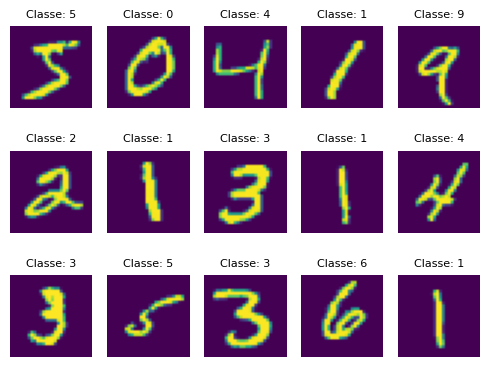

In [4]:
plt.figure(figsize=(5, 4))
for indice in range(15):
    plt.subplot(3, 5, indice + 1)
    plt.imshow(imagens_treino[indice])
    plt.title(f'Classe: {tf.argmax(rotulos_treino_one_hot[indice])}', fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 4. Rede MLP

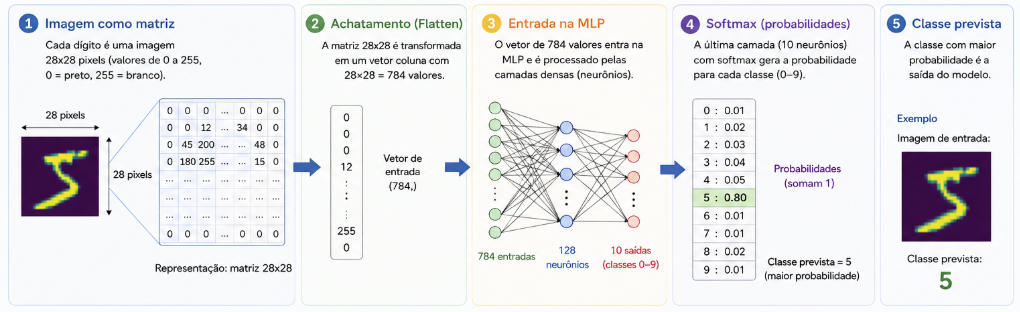

In [5]:
modelo_mlp = tf.keras.models.Sequential([
  tf.keras.layers.Input(shape=(28, 28)),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(10, activation='softmax')
])

### 4.1 Treinamento da rede

In [6]:
modelo_mlp.compile(optimizer='adam', loss='mse', metrics=['mse'])

historico_treinamento = modelo_mlp.fit(
    imagens_treino,
    rotulos_treino_one_hot,
    epochs=5,
    validation_split=0.1
)

Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0123 - mse: 0.0123 - val_loss: 0.0053 - val_mse: 0.0053
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - loss: 0.0060 - mse: 0.0060 - val_loss: 0.0043 - val_mse: 0.0043
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0044 - mse: 0.0044 - val_loss: 0.0036 - val_mse: 0.0036
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0035 - mse: 0.0035 - val_loss: 0.0040 - val_mse: 0.0040
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - loss: 0.0029 - mse: 0.0029 - val_loss: 0.0037 - val_mse: 0.0037


### 4.2 Gráfico do erro de treino e validação

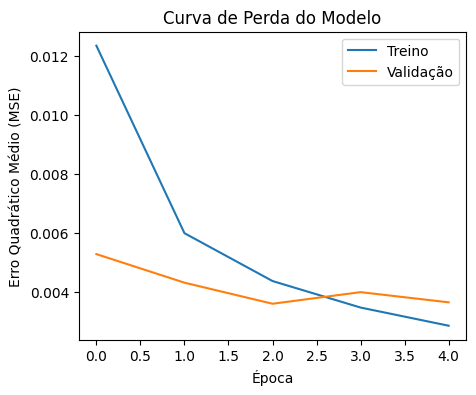

In [7]:
plt.figure(figsize=(5, 4))
plt.plot(historico_treinamento.history['loss'])
plt.plot(historico_treinamento.history['val_loss'])
plt.title('Curva de Perda do Modelo')
plt.ylabel('Erro Quadrático Médio (MSE)')
plt.xlabel('Época')
plt.legend(['Treino', 'Validação'])
plt.show()

### 4.3 Salvar o modelo treinado

In [8]:
modelo_mlp.save('meu_modelo_mnist.keras')

## 5. Teste de inferência com o modelo treinado

In [9]:

modelo_carregado = tf.keras.models.load_model('meu_modelo_mnist.keras')

# Selecionar uma amostra do conjunto de teste
indice_amostra = 0
amostra = imagens_teste[indice_amostra]
amostra_batch = np.expand_dims(amostra, axis=0)
# Realizar a previsão
previsao = modelo_carregado.predict(amostra_batch)
classe_predita = np.argmax(previsao)
classe_real = rotulos_teste[indice_amostra]
print(f'Predição: {classe_predita} | Real: {classe_real}')


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Predição: 7 | Real: 7


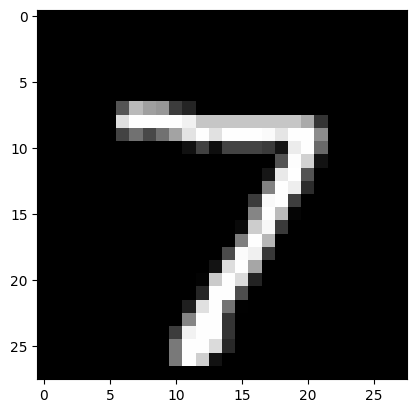

In [10]:
plt.imshow(amostra, cmap='gray')